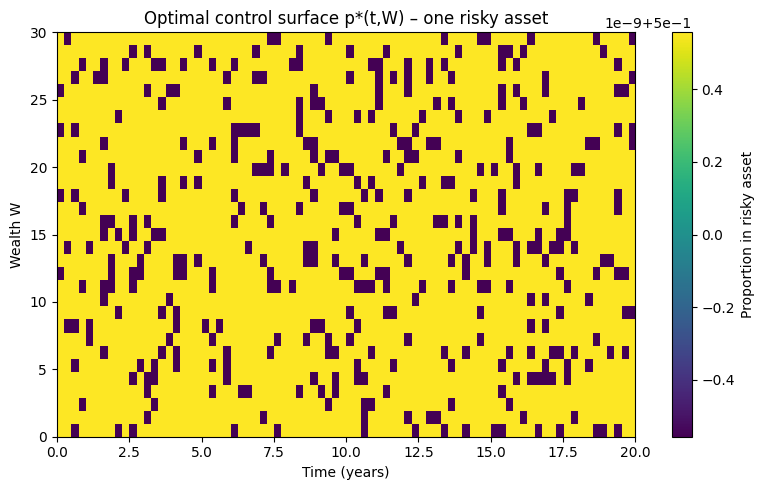

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Problem parameters (one risky asset, no leverage, no short)
# ------------------------------------------------------------------
T      = 20.0          # horizon
dt     = 0.25          # step
N      = int(T/dt)     # 80 steps
K      = 50_000        # MC paths
M      = 31            # wealth grid points  (W0..Wmax)
r      = 0.03          # risk-free rate
mu     = 0.0795        # risky asset growth
sigma  = 0.15
pi     = 0.10          # contribution rate
w0     = 1.0           # initial wealth
p_min  = 0.0
p_max  = 1.0
W_max  = 30.0
λ      = 0.3           # pick any risk-aversion level

# ------------------------------------------------------------------
# 2. Monte-Carlo simulator  (vectorised Euler–Maruyama)
# ------------------------------------------------------------------
rng = np.random.default_rng(12345)

def simulate(p_mat):
    """
    p_mat : (M, N)  – control surface
    returns final wealth vector W_T of shape (K,)
    """
    W = np.full(K, w0, dtype=np.float64)
    # interpolate policy for every (t,W)
    t_grid = np.linspace(0, T, N)
    W_grid = np.linspace(0, W_max, M)

    # fast bilinear interpolation helper
    def policy(t, w):
        # vectorised over paths
        w = np.clip(w, 0, W_max)
        i = np.clip(np.searchsorted(W_grid, w, side='right') - 1, 0, M-2)
        j = np.clip(int(t/dt), 0, N-2)
        alpha = (w - W_grid[i]) / (W_grid[i+1] - W_grid[i])
        beta  = (t - t_grid[j]) / (t_grid[j+1] - t_grid[j])
        p00 = p_mat[i,   j]
        p01 = p_mat[i,   j+1]
        p10 = p_mat[i+1, j]
        p11 = p_mat[i+1, j+1]
        return (1-alpha)*(1-beta)*p00 + alpha*(1-beta)*p10 + \
               (1-alpha)*beta *p01 + alpha*beta *p11

    # path simulation
    Z = rng.standard_normal((N, K))
    for n in range(N):
        t = n*dt
        p = policy(t, W)
        W += W*(r*dt + p*((mu-r)*dt + sigma*np.sqrt(dt)*Z[n])) + pi*dt
    return W

# ------------------------------------------------------------------
# 3. Objective function
# ------------------------------------------------------------------
def objective(x):
    p_mat = x.reshape(M, N)
    p_mat = np.clip(p_mat, p_min, p_max)
    WT = simulate(p_mat)
    EW = WT.mean()
    semivar = np.minimum(WT - EW, 0.0)**2
    return -(EW - λ*semivar.mean())

# ------------------------------------------------------------------
# 4. Optimise
# ------------------------------------------------------------------
x0 = np.full(M*N, 0.5)   # neutral start
bounds = [(p_min, p_max)]*len(x0)

res = minimize(objective, x0, method='L-BFGS-B', bounds=bounds,
               options={'maxiter': 150, 'disp': True})

P_star = res.x.reshape(M, N)
P_star = np.clip(P_star, p_min, p_max)

# ------------------------------------------------------------------
# 5. Plot the optimised control surface
# ------------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.imshow(P_star, aspect='auto', origin='lower',
           extent=[0, T, 0, W_max], cmap='viridis')
plt.colorbar(label='Proportion in risky asset')
plt.xlabel('Time (years)')
plt.ylabel('Wealth W')
plt.title('Optimal control surface p*(t,W) – one risky asset')
plt.tight_layout()
plt.show()